In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.impute import SimpleImputer
import shap
import matplotlib.pyplot as plt
import joblib

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Indian_liver_patient')

print("Shape:", df.shape)
df.head()

Shape: (583, 11)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [4]:
# Target mapping
df['Dataset'] = df['Dataset'].map({1: 1, 2: 0})

# Gender encoding
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Check missing values
print("Missing values BEFORE:\n", df.isnull().sum())

# Fix missing values (IMPORTANT FIX)
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(
    df['Albumin_and_Globulin_Ratio'].mean()
)

print("\nMissing values AFTER:\n", df.isnull().sum())

Missing values BEFORE:
 Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Missing values AFTER:
 Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64


In [5]:
df['bilirubin_ratio'] = df['Direct_Bilirubin'] / df['Total_Bilirubin']
df['enzyme_ratio'] = df['Aspartate_Aminotransferase'] / df['Alamine_Aminotransferase']

In [6]:
X = df.drop('Dataset', axis=1)
y = df['Dataset']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [8]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=params,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [10]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[ 7 27]
 [ 7 76]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.21      0.29        34
           1       0.74      0.92      0.82        83

    accuracy                           0.71       117
   macro avg       0.62      0.56      0.55       117
weighted avg       0.67      0.71      0.66       117


ROC AUC Score: 0.7937632884479092


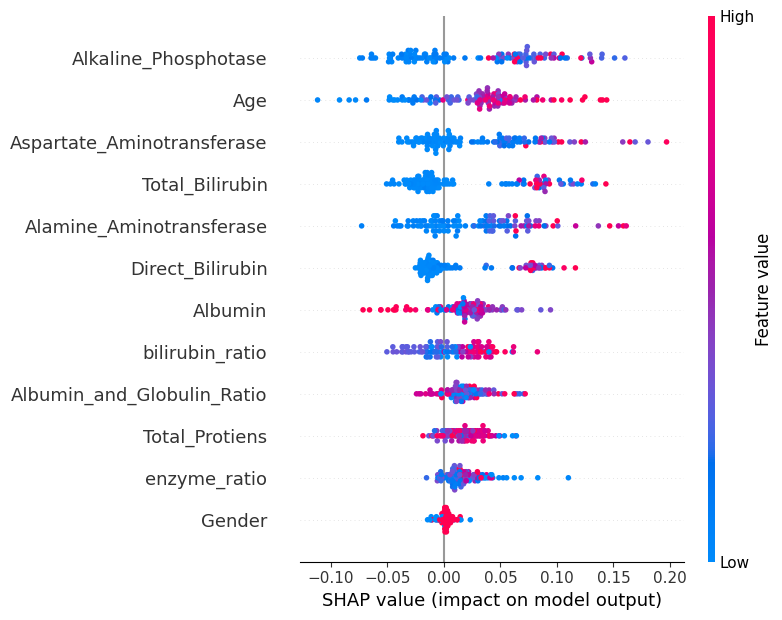

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Get feature names from the original X DataFrame
feature_names = X.columns

# Convert the X_test numpy array back to a DataFrame for plotting, retaining feature names
# This is crucial because X_test was transformed by the imputer into a numpy array
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Now, call summary_plot with the DataFrame
shap.summary_plot(shap_values[:, :, 1], X_test_df) # Corrected indexing for shap_values

In [12]:
# Sample input (same number of features as X)
sample = np.array([[45, 1, 1.2, 0.5, 200, 35, 40, 6.5, 3.2, 1.0, 0.4, 1.1]])

sample = imputer.transform(sample)

prediction = model.predict(sample)
probability = model.predict_proba(sample)[0][1]

print("Prediction:", "Disease" if prediction[0] == 1 else "No Disease")
print("Probability:", probability)

Prediction: Disease
Probability: 0.725


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [13]:
joblib.dump(model, '/content/drive/MyDrive/liver_model.pkl')
joblib.dump(imputer, '/content/drive/MyDrive/imputer.pkl')

['/content/drive/MyDrive/imputer.pkl']

In [14]:
model = RandomForestClassifier(class_weight={0:2, 1:1})

In [15]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [16]:
y_pred = (y_prob > 0.6).astype(int)

In [17]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.6).astype(int)

In [18]:
!pip install gradio


In [19]:
import gradio as gr
import numpy as np
import joblib

# Load saved model
model = joblib.load('/content/drive/MyDrive/liver_model.pkl')
imputer = joblib.load('/content/drive/MyDrive/imputer.pkl')

In [20]:
def predict_liver(
    Age, Gender, Total_Bilirubin, Direct_Bilirubin,
    Alkaline_Phosphotase, Alamine_Aminotransferase,
    Aspartate_Aminotransferase, Total_Protiens,
    Albumin, Albumin_and_Globulin_Ratio
):

    # Feature engineering (same as training)
    bilirubin_ratio = Direct_Bilirubin / Total_Bilirubin if Total_Bilirubin != 0 else 0
    enzyme_ratio = Aspartate_Aminotransferase / Alamine_Aminotransferase if Alamine_Aminotransferase != 0 else 0

    # Input array
    input_data = np.array([[Age, Gender, Total_Bilirubin, Direct_Bilirubin,
                            Alkaline_Phosphotase, Alamine_Aminotransferase,
                            Aspartate_Aminotransferase, Total_Protiens,
                            Albumin, Albumin_and_Globulin_Ratio,
                            bilirubin_ratio, enzyme_ratio]])

    # Apply imputer
    input_data = imputer.transform(input_data)

    # Prediction
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]

    result = "🟥 Liver Disease Detected" if pred == 1 else "🟩 No Liver Disease"

    return f"{result}\nProbability: {prob:.2f}"

In [21]:
def predict(age, gender, tb, db, alkphos, alt, ast, tp, alb, ag_ratio):
    input_data = np.array([[age, gender, tb, db, alkphos, alt, ast, tp, alb, ag_ratio]])

    input_data = imputer.transform(input_data)

    prob = model.predict_proba(input_data)[0][1]

    # Risk Classification
    if prob < 0.3:
        risk = "🟢 Healthy"
        message = "Liver condition appears normal. Maintain a healthy lifestyle."
    elif prob < 0.7:
        risk = "🟡 Risk Zone"
        message = "There may be some risk. It is advisable to consult a doctor."
    else:
        risk = "🔴 High Risk"
        message = "High probability of liver disease. Immediate medical attention is recommended."

    return f"""
Prediction Probability: {prob:.2f}

Risk Level: {risk}

Message: {message}
"""

In [22]:
interface = gr.Interface(
    fn=predict_liver,
    inputs=[
        gr.Number(label="Age"),
        gr.Radio([1, 0], label="Gender (1 = Male, 0 = Female)"),
        gr.Number(label="Total Bilirubin"),
        gr.Number(label="Direct Bilirubin"),
        gr.Number(label="Alkaline Phosphotase"),
        gr.Number(label="Alamine Aminotransferase"),
        gr.Number(label="Aspartate Aminotransferase"),
        gr.Number(label="Total Proteins"),
        gr.Number(label="Albumin"),
        gr.Number(label="Albumin and Globulin Ratio"),
    ],
    outputs="text",
    title="AI Liver Disease Detection System",
    description="Enter patient clinical values to predict liver disease risk"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2ecc3bbd2e36d69f8c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
from google.colab import files
files.download("/content/drive/MyDrive/liver_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import os
print(os.path.getsize("/content/drive/MyDrive/liver_model.pkl"))

2787705
